In [1]:
%config InlineBackend.figure_format = 'retina'

In [2]:
from common import *

default figsize: (3.3339558599695587, 2.0604980384530722)


In [3]:
df = read_trace("2.csv")
df.head(n=20)

,type,timestamp_us,count,layer_idx,seq_len,token_idx
0,StartTracing,0,<NA>,<NA>,<NA>,<NA>
1,CheckpointBegin,7247573,<NA>,<NA>,<NA>,<NA>
2,CheckpointComplete,7254708,0,<NA>,<NA>,<NA>
3,CheckpointBegin,7255143,<NA>,<NA>,<NA>,<NA>
4,CheckpointComplete,7259073,0,<NA>,<NA>,<NA>
5,CheckpointBegin,7259266,<NA>,<NA>,<NA>,<NA>
6,CheckpointComplete,7263098,0,<NA>,<NA>,<NA>
7,CheckpointBegin,7263344,<NA>,<NA>,<NA>,<NA>
8,CheckpointComplete,7267302,0,<NA>,<NA>,<NA>
9,CheckpointBegin,7267620,<NA>,<NA>,<NA>,<NA>


In [4]:
# Match checkpoint end events with their corresponding begin events
ends = df[df['type'] == 'CheckpointComplete'][['timestamp_us', 'count']].copy()
begins = df[df['type'] == 'CheckpointBegin'][['timestamp_us']].copy()
begins.columns = ['begin_timestamp']

# Merge to find most recent begin before each end
checkpoint_df = pd.merge_asof(ends, begins, left_on='timestamp_us', right_on='begin_timestamp', direction='backward')
checkpoint_df = checkpoint_df.rename(columns={'timestamp_us': 'end_timestamp'})
checkpoint_df['duration_us'] = checkpoint_df['end_timestamp'] - checkpoint_df['begin_timestamp']
checkpoint_df['event_type'] = 'checkpoint'
checkpoint_df = checkpoint_df[['begin_timestamp', 'end_timestamp', 'duration_us', 'count', 'event_type']]
checkpoint_df

,begin_timestamp,end_timestamp,duration_us,count,event_type
0,7247573,7254708,7135,0,checkpoint
1,7255143,7259073,3930,0,checkpoint
2,7259266,7263098,3832,0,checkpoint
3,7263344,7267302,3958,0,checkpoint
4,7267620,7271703,4083,0,checkpoint
...,...,...,...,...,...
119,13065851,13084236,18385,29,checkpoint
120,13152569,13170798,18229,29,checkpoint
121,13239863,13257786,17923,29,checkpoint
122,13326663,13344991,18328,29,checkpoint


In [5]:
# Match layer complete events with their corresponding begin events
layer_ends = df[df['type'] == 'LayerComplete'][['timestamp_us', 'layer_idx', 'seq_len', 'token_idx']].copy()
layer_begins = df[df['type'] == 'LayerBegin'][['timestamp_us', 'layer_idx', 'seq_len', 'token_idx']].copy()
layer_begins.columns = ['begin_timestamp', 'layer_idx', 'seq_len', 'token_idx']

# Merge to find corresponding begin for each end (matching on layer_idx, seq_len, token_idx)
layer_df = pd.merge_asof(layer_ends, layer_begins, 
                         left_on='timestamp_us', right_on='begin_timestamp', 
                         by=['layer_idx', 'seq_len', 'token_idx'], direction='backward')
layer_df = layer_df.rename(columns={'timestamp_us': 'end_timestamp'})
layer_df['duration_us'] = layer_df['end_timestamp'] - layer_df['begin_timestamp']
layer_df['event_type'] = 'layer'
layer_df = layer_df[['begin_timestamp', 'end_timestamp', 'duration_us', 'layer_idx', 'seq_len', 'token_idx', 'event_type']]
layer_df

,begin_timestamp,end_timestamp,duration_us,layer_idx,seq_len,token_idx,event_type
0,7271834,7315861,44027,9,32,160,layer
1,7326184,7369022,42838,10,32,160,layer
2,7379068,7422031,42963,11,32,160,layer
3,7431805,7474461,42656,12,32,160,layer
4,7485551,7528104,42553,13,32,160,layer
...,...,...,...,...,...,...,...
434,13403170,13405251,2081,23,1,286,layer
435,13405257,13407273,2016,24,1,286,layer
436,13407280,13409306,2026,25,1,286,layer
437,13409312,13411335,2023,26,1,286,layer


In [6]:
# Merge checkpoint and layer dataframes, sort by end_timestamp
merged_df = pd.concat([checkpoint_df, layer_df], ignore_index=True).sort_values('end_timestamp').reset_index(drop=True)
merged_df['duration_ms'] = merged_df['duration_us'] / 1000
merged_df.head(n=30)

,begin_timestamp,end_timestamp,duration_us,count,event_type,layer_idx,seq_len,token_idx,duration_ms
0,7247573,7254708,7135,0,checkpoint,<NA>,<NA>,<NA>,7.135
1,7255143,7259073,3930,0,checkpoint,<NA>,<NA>,<NA>,3.93
2,7259266,7263098,3832,0,checkpoint,<NA>,<NA>,<NA>,3.832
3,7263344,7267302,3958,0,checkpoint,<NA>,<NA>,<NA>,3.958
4,7267620,7271703,4083,0,checkpoint,<NA>,<NA>,<NA>,4.083
5,7271834,7315861,44027,<NA>,layer,9,32,160,44.027
6,7315880,7326165,10285,32,checkpoint,<NA>,<NA>,<NA>,10.285
7,7326184,7369022,42838,<NA>,layer,10,32,160,42.838
8,7369039,7379046,10007,32,checkpoint,<NA>,<NA>,<NA>,10.007
9,7379068,7422031,42963,<NA>,layer,11,32,160,42.963


In [7]:
# Get all checkpoint events
checkpoint_events = df[df['type'].str.startswith('Checkpoint')].copy()
checkpoint_events = checkpoint_events.sort_values('timestamp_us').reset_index(drop=True)

# Find all checkpoint begin events
checkpoint_begins = checkpoint_events[checkpoint_events['type'] == 'CheckpointBegin'].copy()
checkpoint_begins['checkpoint_id'] = range(len(checkpoint_begins))

# Assign each checkpoint event to its corresponding checkpoint
# Use merge_asof to find the most recent CheckpointBegin before each event
checkpoint_events_with_id = pd.merge_asof(
    checkpoint_events,
    checkpoint_begins[['timestamp_us', 'checkpoint_id']].rename(columns={'timestamp_us': 'begin_timestamp'}),
    left_on='timestamp_us',
    right_on='begin_timestamp',
    direction='backward'
)

# Filter to only events that belong to a checkpoint (have a checkpoint_id)
checkpoint_events_with_id = checkpoint_events_with_id[checkpoint_events_with_id['checkpoint_id'].notna()].copy()
checkpoint_events_with_id['checkpoint_id'] = checkpoint_events_with_id['checkpoint_id'].astype(int)

# Get begin timestamps for each checkpoint
checkpoint_begin_times = checkpoint_begins.set_index('checkpoint_id')['timestamp_us'].to_dict()

# Determine the order of event types (based on first checkpoint's event order)
first_checkpoint_events = checkpoint_events_with_id[
    checkpoint_events_with_id['checkpoint_id'] == checkpoint_events_with_id['checkpoint_id'].min()
].sort_values('timestamp_us')
event_type_order = first_checkpoint_events['type'].tolist()

# Calculate time_to_begin and time_to_previous for each event
results = []
for checkpoint_id in sorted(checkpoint_events_with_id['checkpoint_id'].unique()):
    checkpoint_events_subset = checkpoint_events_with_id[
        checkpoint_events_with_id['checkpoint_id'] == checkpoint_id
    ].sort_values('timestamp_us').reset_index(drop=True)
    
    begin_timestamp = checkpoint_begin_times[checkpoint_id]
    
    row_data = {}
    
    prev_timestamp = begin_timestamp
    for idx, event in checkpoint_events_subset.iterrows():
        event_type = event['type']
        event_timestamp = event['timestamp_us']
        
        time_to_begin = event_timestamp - begin_timestamp
        time_to_previous = event_timestamp - prev_timestamp
        
        row_data[event_type] = (time_to_begin, time_to_previous)
        prev_timestamp = event_timestamp
    
    results.append(row_data)

# Create DataFrame from results
checkpoint_analysis_df = pd.DataFrame(results)

# Reorder columns to match event_type_order
existing_cols = [col for col in event_type_order if col in checkpoint_analysis_df.columns]
checkpoint_analysis_df = checkpoint_analysis_df[existing_cols]

# Display the table
checkpoint_analysis_df

,CheckpointBegin,CheckpointComplete
0,"(0, 0)","(7135, 7135)"
1,"(0, 0)","(3930, 3930)"
2,"(0, 0)","(3832, 3832)"
3,"(0, 0)","(3958, 3958)"
4,"(0, 0)","(4083, 4083)"
...,...,...
119,"(0, 0)","(18385, 18385)"
120,"(0, 0)","(18229, 18229)"
121,"(0, 0)","(17923, 17923)"
122,"(0, 0)","(18328, 18328)"


(<Figure size 500.093x309.075 with 1 Axes>, <Axes: >)

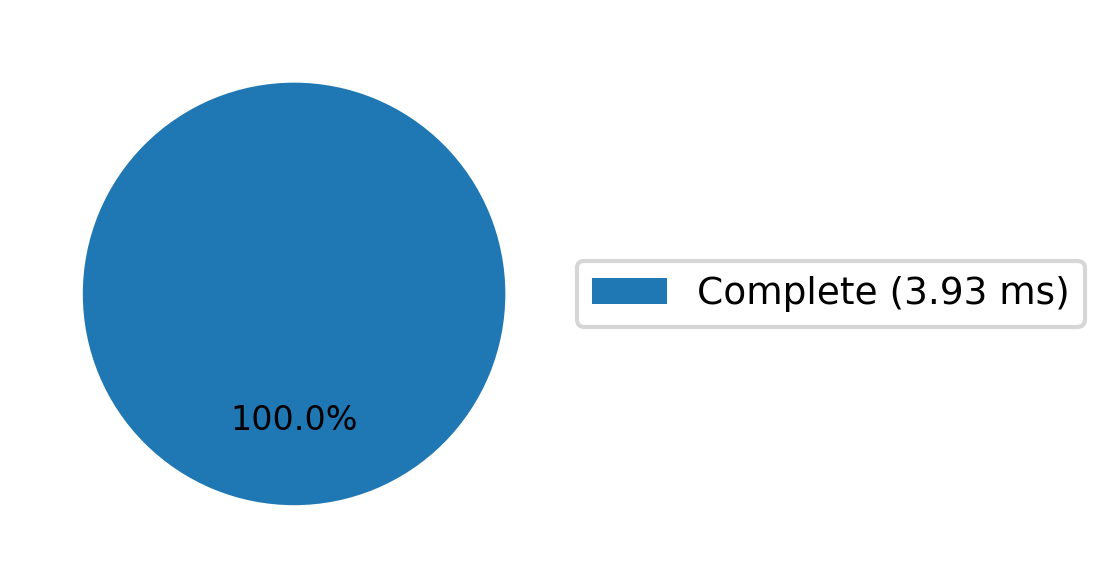

In [8]:
def plot_checkpoint_pie(row):
    """Plot a pie chart showing the cost breakdown of each component for a checkpoint."""
    components = []
    times = []
    
    for col, value in row.items():
        if pd.notna(value):
            _, time_to_previous = value
            component_name = col.replace('Checkpoint', '')
            if component_name != 'Begin' and time_to_previous > 0:
                components.append(component_name)
                times.append(time_to_previous)
    
    fig, ax = plt.subplots(figsize=figsize)
    wedges, texts, autotexts = ax.pie(
        times, 
        labels=None,  # No labels on pie slices
        autopct='%1.1f%%', 
        startangle=90,
        textprops={'fontsize': font_size - 1}
    )
    
    # Use legend instead of labels to avoid overlap
    ax.legend(wedges, [f'{c} ({t/1000:.2f} ms)' for c, t in zip(components, times)],
              loc='center left', bbox_to_anchor=(1, 0, 0.5, 1), fontsize=font_size)
    
    plt.tight_layout()
    return fig, ax

# Example: plot pie chart for first checkpoint
plot_checkpoint_pie(checkpoint_analysis_df.iloc[1])